In [1]:
import jax
import jax.numpy as jnp, jax.random as jr
from msvgd import MSVGD

import matplotlib.pyplot as plt

# Bivariate Gaussian

In [2]:
def gaussian_logdensity(x):
    """
    Log-density of the 2D Gaussian distribution.
    x : shape (2,) — as expected by MSVGD's logdensity argument
    returns : shape (1,)
    """
    return -x**2/2

In [3]:
gaussian_solver = MSVGD(gaussian_logdensity)
x0 = jr.normal(jr.PRNGKey(1), shape=(200, 2))
_ = gaussian_solver.solve(x0, mitosis_splits=3)

Split 0 finished after 36 iterations | max grad = 0.00999
Split 1 finished after 30 iterations | max grad = 0.00989
Split 2 finished after 11 iterations | max grad = 0.00970
Split 3 finished after 7 iterations | max grad = 0.00978


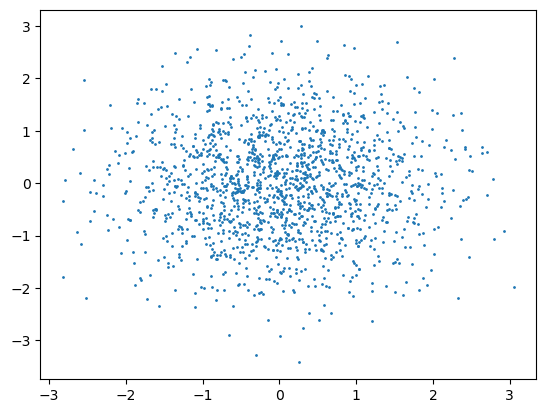

In [4]:
plt.scatter(gaussian_solver.particles[:,0], gaussian_solver.particles[:,1], s=1)
plt.show()

# Rosenbrock

##### This is a harder distribution, which we can learn more easily by employing an annealing strategy, for which we use the variable `T`

In [5]:
a = 1 / 20
b = 5

def rosenbrock_logdensity(x, T):
    """
    Log-density of the 2D Rosenbrock distribution.
    x : shape (2,) — as expected by MSVGD's logdensity argument
    returns : shape (1,)
    """
    x1, x2 = x
    return (-a*(1 - x1)**2 - b*((x2 - x1**2)**2)) / T

In [6]:
key = jr.PRNGKey(2)
x0 = jr.normal(key, shape=(200, 2))

for i, T in enumerate(jnp.arange(21, 1, -4)):
    rosenbrock_solver = MSVGD(lambda x: rosenbrock_logdensity(x, T))
    x0 = rosenbrock_solver.solve(x0, key=jr.fold_in(key, i), mitosis_splits=max([2-i, 0]), atol=5e-3)

Split 0 finished after 3088 iterations | max grad = 0.00500
Split 1 finished after 2435 iterations | max grad = 0.00499
Split 2 finished after 2098 iterations | max grad = 0.00500
Split 0 finished after 19 iterations | max grad = 0.00469
Split 1 finished after 1850 iterations | max grad = 0.00500
Split 0 finished after 162 iterations | max grad = 0.00498
Split 0 finished after 30 iterations | max grad = 0.00409
Split 0 finished after 48 iterations | max grad = 0.00469


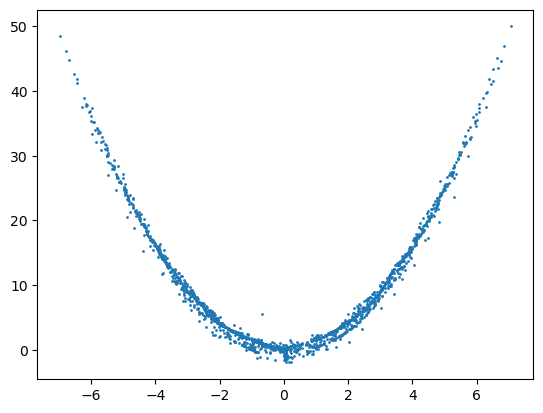

In [7]:
plt.scatter(rosenbrock_solver.particles[:,0], rosenbrock_solver.particles[:,1], s=1)
plt.show()

# Normal Inverse-Chisquare

##### The chisquare component of this distribution is strictly positive. One way to handle this is to set the log-density of negative values to -inf, but it is more stable to reparametrize it by its log.

In [8]:
mu0    = 0.0
kappa0 = 1.0
nu0    = 3.0
sigma0_sq = 1.0

def normal_inverse_chi2_logdensity_reparam(x):
    """
    Reparametrized log-density of the Normal Inverse-Chisquare distribution.
    x : shape (2,) — as expected by MSVGD's logdensity argument
        x[0] is mu, x[1] is psi = log(sigma^2)
    returns : shape (1,)
    Jacobian term log|d(sigma^2)/d(psi)| = psi is added for correct density.
    """
    mu, psi  = x
    var = jnp.exp(psi)

    return (
        -(nu0 + 3) / 2 * psi
        - (nu0 * sigma0_sq + kappa0 * (mu - mu0) ** 2) / (2 * var)
        + psi
    )

In [9]:
nix_solver = MSVGD(normal_inverse_chi2_logdensity_reparam)
x0 = jr.normal(jr.PRNGKey(3), shape=(200, 2))
_ = nix_solver.solve(x0, mitosis_splits=3)

Split 0 finished after 308 iterations | max grad = 0.00999
Split 1 finished after 42 iterations | max grad = 0.00950
Split 2 finished after 31 iterations | max grad = 0.00987
Split 3 finished after 42 iterations | max grad = 0.00999


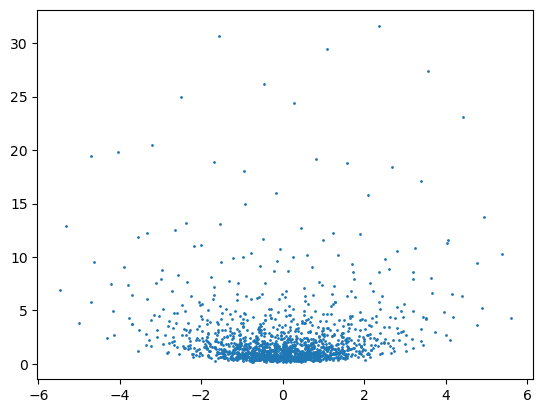

In [10]:
plt.scatter(nix_solver.particles[:,0], jnp.exp(nix_solver.particles[:,1]), s=1)
plt.show()

# Gaussian Ring Mixture

In [11]:
n_modes = 6
radius  = 3.0
sigma2  = 0.1

# Mode centers arranged evenly around a circle
angles  = jnp.linspace(0, 2 * jnp.pi, n_modes, endpoint=False)
centres = jnp.stack([radius * jnp.cos(angles),
                     radius * jnp.sin(angles)], axis=1) # (n_modes, 2)

def ring_mixture_logdensity(x, T):
    """
    Log-density of a ring mixture of bivariate Gaussian distributions.
    x : (2,) — as expected by MSVGD
    returns : (1,)
    """
    log_weights = jnp.zeros(n_modes) # uniform mixture
    sq_dists = jnp.sum((centres - x) ** 2, axis=1) # (n_modes,)
    log_kernels = -sq_dists / (2 * sigma2) # (n_modes,)
    return jnp.array([jax.nn.logsumexp(log_weights + log_kernels)]) / T

In [12]:
key = jr.PRNGKey(4)
x0 = jr.normal(key, shape=(200, 2))

for i, T in enumerate(jnp.arange(21, 1, -4)):
    grm_solver = MSVGD(lambda x: ring_mixture_logdensity(x, T))
    x0 = grm_solver.solve(x0, key=jr.fold_in(key, i), mitosis_splits=max([2-i, 0]), atol=5e-3)

Split 0 finished after 866 iterations | max grad = 0.00500
Split 1 finished after 70 iterations | max grad = 0.00495
Split 2 finished after 80 iterations | max grad = 0.00483
Split 0 finished after 24 iterations | max grad = 0.00494
Split 1 finished after 93 iterations | max grad = 0.00494
Split 0 finished after 49 iterations | max grad = 0.00495
Split 0 finished after 67 iterations | max grad = 0.00492
Split 0 finished after 105 iterations | max grad = 0.00492


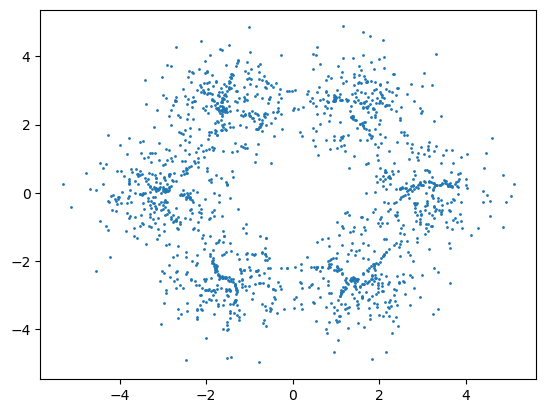

In [13]:
plt.scatter(grm_solver.particles[:,0], grm_solver.particles[:,1], s=1)
plt.show()